<a href="https://colab.research.google.com/github/Daniele-DevSoftware/Trabalho_Extensionista_Big_Data/blob/main/Trabalho_Base_de_Dados_Big_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, trim, count, avg, sum as _sum, max as _max, min as _min, stddev

sc = SparkSession.builder.master('local[*]').getOrCreate()
MUNICIPIO, UF, UF_EXT = "São Gonçalo", "RJ", "Rio de Janeiro"

In [ ]:
cols1 = ["Codigo do IBGE","Município","UF","Atendimento da população total com rede de abastecimento de água",
         "Atendimento da população urbana com rede de abastecimento de água","Atendimento da população rural com rede de abastecimento de água",
         "Atendimento dos domicílios totais com rede de abastecimento de água","Atendimento dos domicílios urbanos com rede de abastecimento de água",
         "Atendimento dos domicílios rurais com rede de abastecimento de água"]
dados_atendimento = sc.createDataFrame(pd.read_excel("/content/SINISA_AGUA_Indicadores_Base Municipal_2023_V2.xlsx", sheet_name="Atendimento", header=7)[cols1])
dados_atendimento_sg = dados_atendimento.filter((col("UF")==UF) & (col("Município")==MUNICIPIO)).select(*cols1)
dados_atendimento_sg.show(truncate=False)

+--------------+-----------+---+----------------------------------------------------------------+-----------------------------------------------------------------+----------------------------------------------------------------+-------------------------------------------------------------------+--------------------------------------------------------------------+-------------------------------------------------------------------+
|Codigo do IBGE|Município  |UF |Atendimento da população total com rede de abastecimento de água|Atendimento da população urbana com rede de abastecimento de água|Atendimento da população rural com rede de abastecimento de água|Atendimento dos domicílios totais com rede de abastecimento de água|Atendimento dos domicílios urbanos com rede de abastecimento de água|Atendimento dos domicílios rurais com rede de abastecimento de água|
+--------------+-----------+---+----------------------------------------------------------------+-----------------------------------

In [ ]:
cols2 = ["Codigo do IBGE","Município","UF","População Total Residente ","Investimento total realizado pelo prestador para o serviço de abastecimento de água"]
dados_adm_financeiro = sc.createDataFrame(pd.read_excel("/content/SINISA_AGUA_Informacoes_Administrativo e Financeiro_Base Municipal_2023_V2.xlsx", sheet_name="Administrativo_Financeiro", header=8)[cols2])
dados_adm_financeiro_sg = dados_adm_financeiro.filter((col("UF")==UF) & (col("Município")==MUNICIPIO)).select(*cols2)
dados_adm_financeiro_sg.show(truncate=False)

+--------------+-----------+---+--------------------------+-----------------------------------------------------------------------------------+
|Codigo do IBGE|Município  |UF |População Total Residente |Investimento total realizado pelo prestador para o serviço de abastecimento de água|
+--------------+-----------+---+--------------------------+-----------------------------------------------------------------------------------+
|3304904       |São Gonçalo|RJ |905630                    |1.4964460025E8                                                                     |
+--------------+-----------+---+--------------------------+-----------------------------------------------------------------------------------+



In [ ]:
cols3 = ["Codigo do IBGE","Município","UF","População Total Residente ","População urbana atendida com rede de abastecimento de água",
         "População rural atendida com rede de abastecimento de água","Volume de água tratada em ETAs","Volume de água consumido",
         "Quantidade de reclamações recebidas por falta de água","Quantidade de reclamações recebidas sobre vazamentos no sistema de distribuição",
         "Quantidade de vazamentos de água reparados no sistema de distribuição","Quantidade de dias que o sistema ficou em colapso"]
dados_gestao_tecnica = sc.createDataFrame(pd.read_excel("/content/SINISA_AGUA_Informacoes_Gestao Tecnica Agua_Base Municipal_2023_V2.xlsx", sheet_name="Gestão Técnica de Água", header=8)[cols3])
dados_gestao_tecnica_sg = dados_gestao_tecnica.filter((col("UF")==UF) & (col("Município")==MUNICIPIO)).select(*cols3)
dados_gestao_tecnica_sg.show(truncate=False)

+--------------+-----------+---+--------------------------+-----------------------------------------------------------+----------------------------------------------------------+------------------------------+------------------------+-----------------------------------------------------+-------------------------------------------------------------------------------+---------------------------------------------------------------------+-------------------------------------------------+
|Codigo do IBGE|Município  |UF |População Total Residente |População urbana atendida com rede de abastecimento de água|População rural atendida com rede de abastecimento de água|Volume de água tratada em ETAs|Volume de água consumido|Quantidade de reclamações recebidas por falta de água|Quantidade de reclamações recebidas sobre vazamentos no sistema de distribuição|Quantidade de vazamentos de água reparados no sistema de distribuição|Quantidade de dias que o sistema ficou em colapso|
+--------------+------

In [ ]:
anos = range(2016, 2023)
cols_val = [f"{a}_{s}" for a in anos for s in ["Total","Homens","Mulheres"]]
raw1 = pd.read_csv("/content/tabela8191.csv", sep=";", header=None, skiprows=5, nrows=14, encoding="utf-8-sig")
raw1.columns = ["UF","Grupo_idade"] + cols_val
raw1 = raw1[raw1["UF"].str.strip()==UF_EXT]
raw1[cols_val] = raw1[cols_val].apply(lambda s: s.str.replace(",", ".").astype(float))
dados_mortalidade = sc.createDataFrame(raw1)
dados_mortalidade_sg = dados_mortalidade.filter((trim(col("UF"))==UF_EXT) & (trim(col("Grupo_idade"))=="Total")).select("UF","Grupo_idade", *[f"{a}_Total" for a in anos])
dados_mortalidade_sg.show(truncate=False)

+--------------+-----------+----------+----------+----------+----------+----------+----------+----------+
|UF            |Grupo_idade|2016_Total|2017_Total|2018_Total|2019_Total|2020_Total|2021_Total|2022_Total|
+--------------+-----------+----------+----------+----------+----------+----------+----------+----------+
|Rio de Janeiro|Total      |4.7       |3.8       |3.6       |3.6       |2.9       |2.6       |3.0       |
+--------------+-----------+----------+----------+----------+----------+----------+----------+----------+



In [ ]:
raw2 = pd.read_csv("/content/transmissao_de_doencas.csv", sep=";", header=None, skiprows=5, nrows=28, encoding="utf-8-sig")
raw2.columns = ["UF","Total","Feco_oral","Inseto_vetor","Contato_agua","Higiene","Geo_helmintos_teniases"]
raw2[raw2.columns[1:]] = raw2[raw2.columns[1:]].apply(lambda s: s.str.replace(",", ".").astype(float))
dados_internacoes = sc.createDataFrame(raw2)
dados_internacoes_sg = dados_internacoes.filter(trim(col("UF"))==UF_EXT).select("UF","Total","Feco_oral","Inseto_vetor","Contato_agua","Higiene","Geo_helmintos_teniases")
dados_internacoes_sg.show(truncate=False)

+--------------+-----+---------+------------+------------+-------+----------------------+
|UF            |Total|Feco_oral|Inseto_vetor|Contato_agua|Higiene|Geo_helmintos_teniases|
+--------------+-----+---------+------------+------------+-------+----------------------+
|Rio de Janeiro|40.7 |24.9     |14.4        |0.8         |0.1    |0.5                   |
+--------------+-----+---------+------------+------------+-------+----------------------+



In [ ]:
dados_atendimento_sg.select(count(dados_atendimento_sg.Município).alias("qtd_municipios_encontrados_sao_goncalo")).show()
dados_atendimento_sg.select(avg(dados_atendimento_sg["Atendimento dos domicílios totais com rede de abastecimento de água"]).alias("pct_domicilios_sao_goncalo_com_agua")).show()
dados_gestao_tecnica_sg.select(_sum(dados_gestao_tecnica_sg["Volume de água consumido"]).alias("volume_agua_consumido_sao_goncalo_m3")).show()
dados_mortalidade_sg.select(
    _max(dados_mortalidade_sg["2016_Total"]).alias("taxa_mortalidade_saneamento_rj_2016"),
    _min(dados_mortalidade_sg["2022_Total"]).alias("taxa_mortalidade_saneamento_rj_2022")
).show()
dados_internacoes_sg.select(count(dados_internacoes_sg.Contato_agua).alias("qtd_categorias_doencas_transmitidas_pela_agua_rj")).show()

+--------------------------------------+
|qtd_municipios_encontrados_sao_goncalo|
+--------------------------------------+
|                                     1|
+--------------------------------------+

+-----------------------------------+
|pct_domicilios_sao_goncalo_com_agua|
+-----------------------------------+
|                              83.12|
+-----------------------------------+

+------------------------------------+
|volume_agua_consumido_sao_goncalo_m3|
+------------------------------------+
|                            55763.98|
+------------------------------------+

+-----------------------------------+-----------------------------------+
|taxa_mortalidade_saneamento_rj_2016|taxa_mortalidade_saneamento_rj_2022|
+-----------------------------------+-----------------------------------+
|                                4.7|                                3.0|
+-----------------------------------+-----------------------------------+

+-----------------------------------

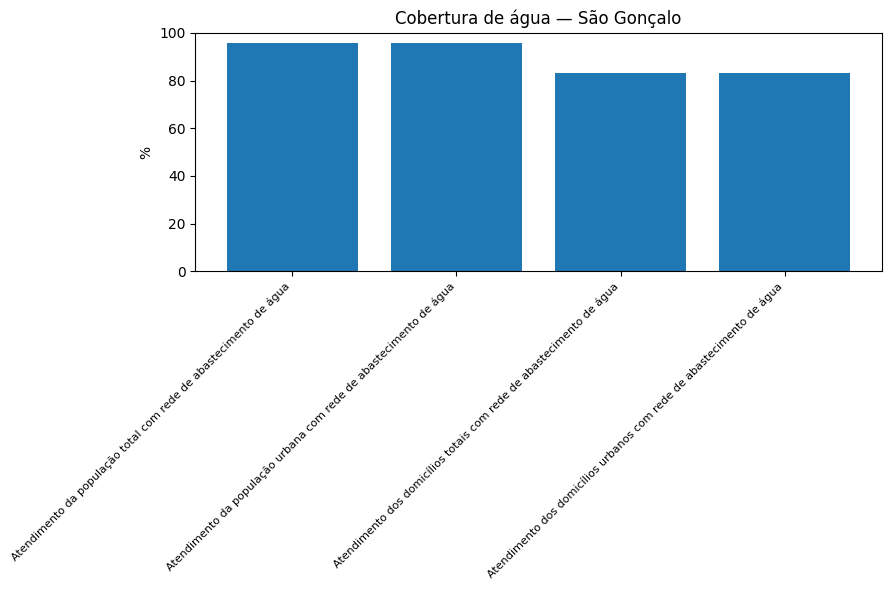

In [ ]:
metricas1 = ["Atendimento da população total com rede de abastecimento de água","Atendimento da população urbana com rede de abastecimento de água",
             "Atendimento dos domicílios totais com rede de abastecimento de água","Atendimento dos domicílios urbanos com rede de abastecimento de água"]
valores1 = dados_atendimento_sg.select(*metricas1).toPandas().iloc[0].astype(float)

plt.figure(figsize=(9,6))
plt.bar(range(len(metricas1)), valores1)
plt.xticks(range(len(metricas1)), metricas1, rotation=45, ha="right", fontsize=8)
plt.ylim(0, 100)
plt.ylabel("%")
plt.title("Cobertura de água — São Gonçalo")
plt.tight_layout()
plt.show()

In [ ]:
COL2 = "Investimento total realizado pelo prestador para o serviço de abastecimento de água"
pdf2_br = pd.read_excel("/content/SINISA_AGUA_Informacoes_Administrativo e Financeiro_Base Municipal_2023_V2.xlsx", sheet_name="Administrativo_Financeiro", header=8)[["Município","UF",COL2]].astype({COL2: str})
dados2_limpo = sc.createDataFrame(pdf2_br).filter(col(COL2).rlike("^[0-9]+([.,][0-9]+)?$")).withColumn(COL2, col(COL2).cast("double"))
dados2_limpo.select(stddev(COL2).alias("desvio_padrao_nacional_investimento_agua")).show()

q1_2, q3_2 = dados2_limpo.approxQuantile(COL2, [0.25, 0.75], 0.01)
ls_2 = q3_2 + 1.5*(q3_2-q1_2)
dados2_limpo.filter((col("UF")=="RJ") & (col("Município")=="São Gonçalo")) \
    .select("Município", COL2, (col(COL2) > ls_2).alias("eh_outlier_nacional")).show(truncate=False)

+----------------------------------------+
|desvio_padrao_nacional_investimento_agua|
+----------------------------------------+
|                    2.2701956533522792E7|
+----------------------------------------+

+-----------+-----------------------------------------------------------------------------------+-------------------+
|Município  |Investimento total realizado pelo prestador para o serviço de abastecimento de água|eh_outlier_nacional|
+-----------+-----------------------------------------------------------------------------------+-------------------+
|São Gonçalo|1.4964460025E8                                                                     |true               |
+-----------+-----------------------------------------------------------------------------------+-------------------+



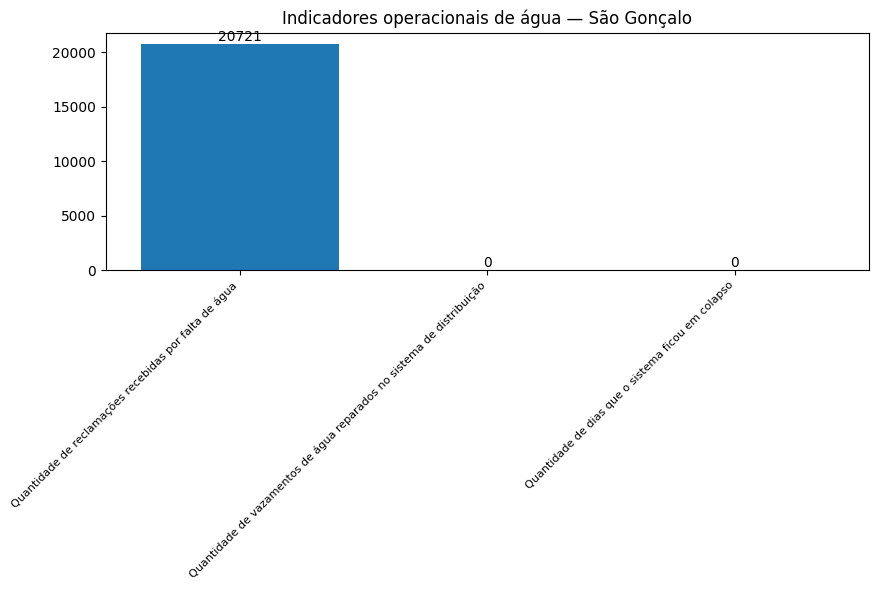

In [ ]:
metricas3 = ["Quantidade de reclamações recebidas por falta de água","Quantidade de vazamentos de água reparados no sistema de distribuição","Quantidade de dias que o sistema ficou em colapso"]
valores3 = dados_gestao_tecnica_sg.select(*metricas3).fillna(0).toPandas().iloc[0].astype(float)

plt.figure(figsize=(9,6))
barras = plt.bar(range(len(metricas3)), valores3)
plt.xticks(range(len(metricas3)), metricas3, rotation=45, ha="right", fontsize=8)
for b, v in zip(barras, valores3):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:.0f}", ha="center", va="bottom")
plt.title("Indicadores operacionais de água — São Gonçalo")
plt.tight_layout()
plt.show()

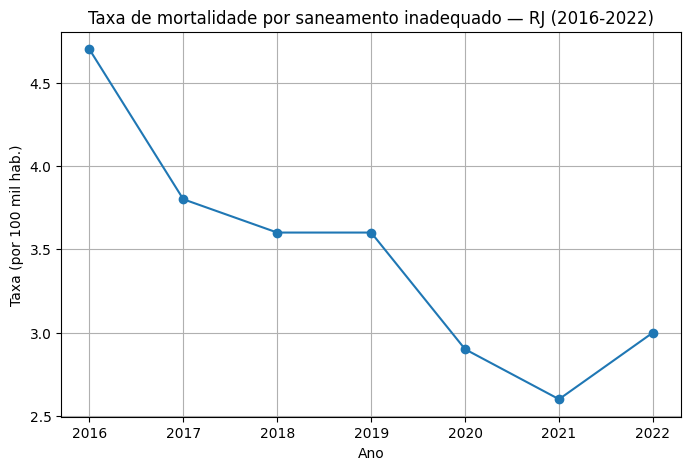

In [ ]:
linha_mortalidade = dados_mortalidade_sg.toPandas().iloc[0]
valores_taxa = [linha_mortalidade[f"{ano}_Total"] for ano in anos]

plt.figure(figsize=(8,5))
plt.plot(anos, valores_taxa, marker="o")
plt.title("Taxa de mortalidade por saneamento inadequado — RJ (2016-2022)")
plt.xlabel("Ano"); plt.ylabel("Taxa (por 100 mil hab.)"); plt.grid(True)
plt.show()

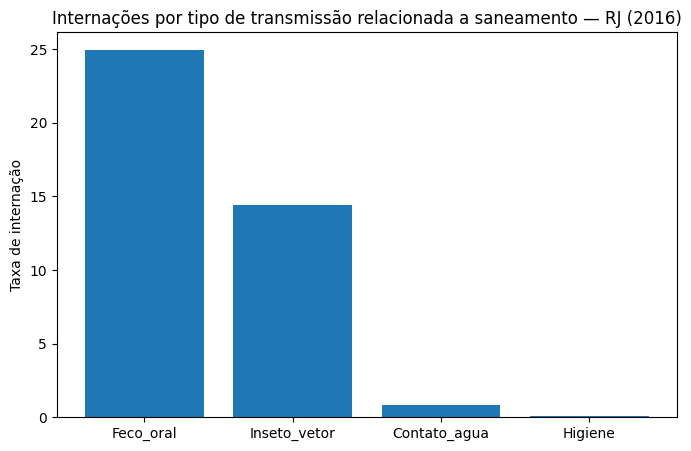

In [ ]:
categorias5 = ["Feco_oral", "Inseto_vetor", "Contato_agua", "Higiene"]
plt.figure(figsize=(8,5))
plt.bar(categorias5, dados_internacoes_sg.select(*categorias5).toPandas().iloc[0])
plt.title("Internações por tipo de transmissão relacionada a saneamento — RJ (2016)")
plt.ylabel("Taxa de internação")
plt.show()